Dataset: Netflix-inspired Movie Watch History (7501 user sessions, up to 10 movies each)

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from itertools import combinations
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [25]:
dataset = pd.read_csv('movies_dataset.csv', header=None)
dataset.head()

,0,1,2,3,4,5,6,7,8,9
0,Iron Man,Twilight,Guardians of the Galaxy,The Avengers,Avengers,NaN,NaN,NaN,NaN,NaN
1,Shrek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Man of Steel,Logan,The Dark Knight,Deadpool,Aquaman,Wonder Woman,Batman v Superman,Venom,Joker,NaN
3,The Avengers,The Dark Knight,Doctor Strange,Logan,Guardians of the Galaxy,Joker,Thor,NaN,NaN,NaN
4,Ant-Man,Captain America,Doctor Strange,Black Panther,Iron Man,Thor,NaN,NaN,NaN,NaN


In [26]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       7501 non-null   str  
 1   1       6350 non-null   str  
 2   2       5249 non-null   str  
 3   3       4037 non-null   str  
 4   4       3278 non-null   str  
 5   5       2636 non-null   str  
 6   6       1942 non-null   str  
 7   7       1230 non-null   str  
 8   8       745 non-null    str  
 9   9       339 non-null    str  
dtypes: str(10)
memory usage: 586.1 KB


In [27]:
dataset.values

array([['Iron Man', 'Twilight', 'Guardians of the Galaxy', ..., nan, nan,
        nan],
       ['Shrek', nan, nan, ..., nan, nan, nan],
       ['Man of Steel', 'Logan', 'The Dark Knight', ..., 'Venom',
        'Joker', nan],
       ...,
       ['Mission: Impossible', nan, nan, ..., nan, nan, nan],
       ['Twilight', 'Mad Max: Fury Road', 'John Wick', ..., nan, nan,
        nan],
       ['Twilight', nan, nan, ..., nan, nan, nan]],
      shape=(7501, 10), dtype=object)

In [28]:
dataset = dataset.replace('Avengers', 'The Avengers')
dataset.head()

,0,1,2,3,4,5,6,7,8,9
0,Iron Man,Twilight,Guardians of the Galaxy,The Avengers,The Avengers,NaN,NaN,NaN,NaN,NaN
1,Shrek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Man of Steel,Logan,The Dark Knight,Deadpool,Aquaman,Wonder Woman,Batman v Superman,Venom,Joker,NaN
3,The Avengers,The Dark Knight,Doctor Strange,Logan,Guardians of the Galaxy,Joker,Thor,NaN,NaN,NaN
4,Ant-Man,Captain America,Doctor Strange,Black Panther,Iron Man,Thor,NaN,NaN,NaN,NaN


In [29]:
dataset.values

array([['Iron Man', 'Twilight', 'Guardians of the Galaxy', ..., nan, nan,
        nan],
       ['Shrek', nan, nan, ..., nan, nan, nan],
       ['Man of Steel', 'Logan', 'The Dark Knight', ..., 'Venom',
        'Joker', nan],
       ...,
       ['Mission: Impossible', nan, nan, ..., nan, nan, nan],
       ['Twilight', 'Mad Max: Fury Road', 'John Wick', ..., nan, nan,
        nan],
       ['Twilight', nan, nan, ..., nan, nan, nan]],
      shape=(7501, 10), dtype=object)

## Preprocessing

In [7]:
import pickle

transactions = []
for i in range(0, 7501):
    transactions.append([str(dataset.values[i, j])
                         for j in range(0, 10)
                         if pd.notna(dataset.values[i, j])])

with open("transactions.pkl", "wb") as f:
    pickle.dump(transactions, f)

In [30]:
import pickle

with open("transactions.pkl", "rb") as f:
    transactions = pickle.load(f)
    print(transactions)

[['Iron Man', 'Twilight', 'Guardians of the Galaxy', 'The Avengers', 'The Avengers'], ['Shrek'], ['Man of Steel', 'Logan', 'The Dark Knight', 'Deadpool', 'Aquaman', 'Wonder Woman', 'Batman v Superman', 'Venom', 'Joker'], ['The Avengers', 'The Dark Knight', 'Doctor Strange', 'Logan', 'Guardians of the Galaxy', 'Joker', 'Thor'], ['Ant-Man', 'Captain America', 'Doctor Strange', 'Black Panther', 'Iron Man', 'Thor'], ['WALL-E', 'Toy Story'], ['The Hunger Games', 'Jurassic Park', 'Interstellar', 'Star Wars', 'John Wick', 'Mission: Impossible', 'Mad Max: Fury Road', 'Inception', 'Avatar', 'The Matrix'], ['La La Land', 'Titanic'], ['Twilight', 'La La Land'], ['Forrest Gump', 'Gone Girl', 'The Godfather', 'Pulp Fiction'], ['Titanic', 'Mad Max: Fury Road', 'Mission: Impossible', 'La La Land', 'John Wick'], ['Frozen', 'WALL-E'], ['The Matrix', 'Inception', 'The Dark Knight', 'Avatar', 'Jurassic Park', 'The Hunger Games', 'Aquaman', 'Venom'], ['The Hunger Games', 'Avatar', 'Inception', 'Forrest Gu

## Visualization 1: Genre Distribution

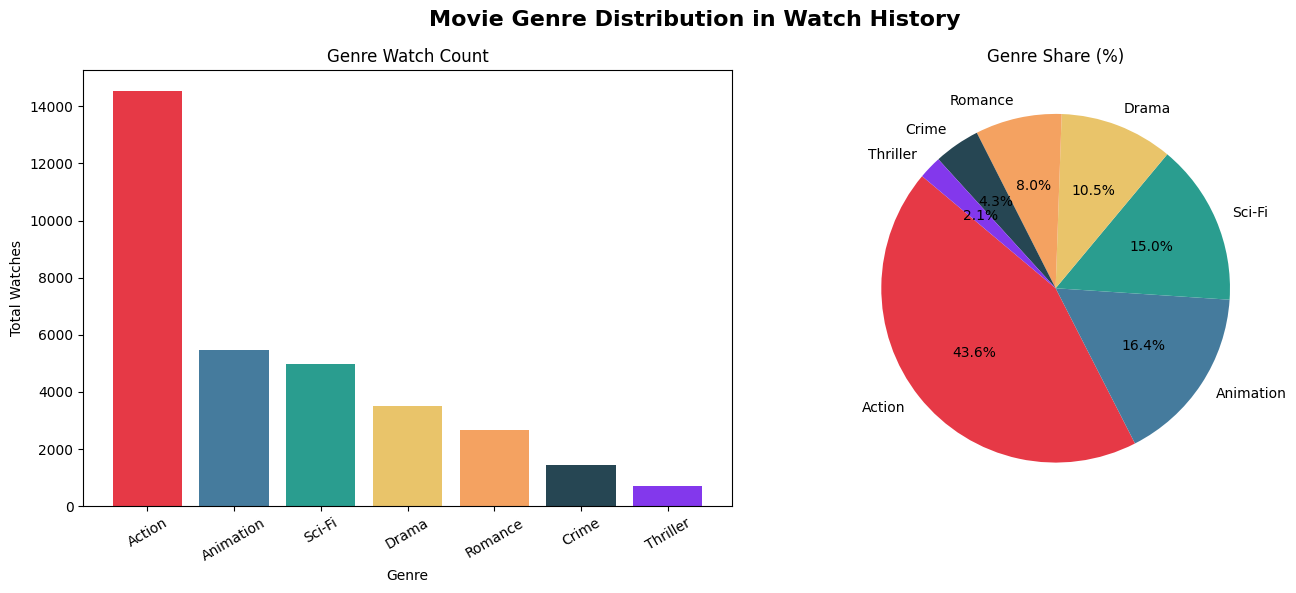

Genre Distribution saved.


In [31]:
genre_map = {
    'Inception': 'Sci-Fi', 'The Dark Knight': 'Action', 'Interstellar': 'Sci-Fi',
    'The Matrix': 'Sci-Fi', 'Avengers': 'Action', 'Iron Man': 'Action',
    'Joker': 'Drama', 'Parasite': 'Thriller', 'The Godfather': 'Crime',
    'Pulp Fiction': 'Crime', 'Fight Club': 'Drama', 'Forrest Gump': 'Drama',
    'The Lion King': 'Animation', 'Titanic': 'Romance', 'Avatar': 'Sci-Fi',
    'Toy Story': 'Animation', 'The Avengers': 'Action', 'Black Panther': 'Action',
    'Guardians of the Galaxy': 'Action', 'Spider-Man': 'Action',
    'Doctor Strange': 'Action', 'Thor': 'Action', 'Captain America': 'Action',
    'Ant-Man': 'Action', 'Shrek': 'Animation', 'Finding Nemo': 'Animation',
    'Up': 'Animation', 'WALL-E': 'Animation', 'Coco': 'Animation', 'Frozen': 'Animation',
    'Harry Potter': 'Fantasy', 'Lord of the Rings': 'Fantasy', 'Star Wars': 'Sci-Fi',
    'Jurassic Park': 'Sci-Fi', 'The Hunger Games': 'Sci-Fi', 'Twilight': 'Romance',
    'Deadpool': 'Action', 'Logan': 'Action', 'Venom': 'Action',
    'Aquaman': 'Action', 'Wonder Woman': 'Action', 'Batman v Superman': 'Action',
    'Man of Steel': 'Action', 'The Social Network': 'Drama', 'Gone Girl': 'Thriller',
    'Whiplash': 'Drama', 'La La Land': 'Romance', 'Mad Max: Fury Road': 'Action',
    'John Wick': 'Action', 'Mission: Impossible': 'Action'
}

# Count genre occurrences
genre_counts = defaultdict(int)
for session in transactions:
    for movie in session:
        genre = genre_map.get(movie, 'Other')
        genre_counts[genre] += 1

genre_df = pd.DataFrame(list(genre_counts.items()), columns=['Genre', 'Count'])
genre_df = genre_df.sort_values('Count', ascending=False)

colors = ['#e63946','#457b9d','#2a9d8f','#e9c46a','#f4a261','#264653','#8338ec']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Movie Genre Distribution in Watch History', fontsize=16, fontweight='bold')

# Bar chart
axes[0].bar(genre_df['Genre'], genre_df['Count'], color=colors[:len(genre_df)])
axes[0].set_title('Genre Watch Count')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Total Watches')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(genre_df['Count'], labels=genre_df['Genre'], autopct='%1.1f%%',
            colors=colors[:len(genre_df)], startangle=140)
axes[1].set_title('Genre Share (%)')

plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Genre Distribution saved.")

## Visualization 2: Top 20 Most Watched Movies

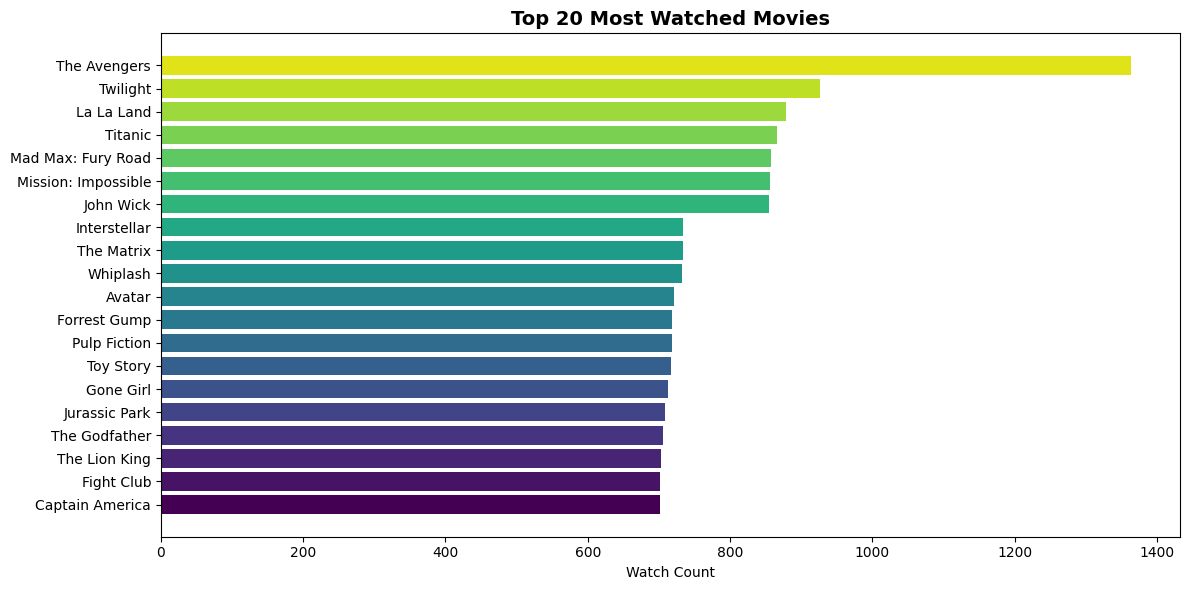

In [32]:
from collections import Counter

all_movies = [movie for session in transactions for movie in session]
movie_counts = Counter(all_movies)
top20 = pd.DataFrame(movie_counts.most_common(20), columns=['Movie', 'Count'])

plt.figure(figsize=(12, 6))
bars = plt.barh(top20['Movie'][::-1], top20['Count'][::-1],
                color=plt.cm.viridis([i/20 for i in range(20)]))
plt.title('Top 20 Most Watched Movies', fontsize=14, fontweight='bold')
plt.xlabel('Watch Count')
plt.tight_layout()
plt.savefig('top20_movies.png', dpi=150, bbox_inches='tight')
plt.show()

## Apriori Algorithm — Custom Implementation

In [33]:
from apyori import apriori

rules = apriori(transactions, min_support=0.003, min_confidence=0.2, min_lift=3, min_length=2)
rules


<generator object apriori at 0x000002126DFC38A0>

In [34]:
rules_list = list(rules)
rules_list

[RelationRecord(items=frozenset({'Ant-Man', 'Black Panther'}), support=0.04906012531662445, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Ant-Man'}), items_add=frozenset({'Black Panther'}), confidence=0.5542168674698795, lift=6.260814341704166), OrderedStatistic(items_base=frozenset({'Black Panther'}), items_add=frozenset({'Ant-Man'}), confidence=0.5542168674698795, lift=6.260814341704166)]),
 RelationRecord(items=frozenset({'Ant-Man', 'Captain America'}), support=0.051593120917211036, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Ant-Man'}), items_add=frozenset({'Captain America'}), confidence=0.5828313253012049, lift=6.236544609250125), OrderedStatistic(items_base=frozenset({'Captain America'}), items_add=frozenset({'Ant-Man'}), confidence=0.5520684736091298, lift=6.236544609250124)]),
 RelationRecord(items=frozenset({'Doctor Strange', 'Ant-Man'}), support=0.045327289694707375, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Ant-Man'}), items_a

In [35]:
len(rules_list)

4017

In [36]:
rules_list[0]

RelationRecord(items=frozenset({'Ant-Man', 'Black Panther'}), support=0.04906012531662445, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Ant-Man'}), items_add=frozenset({'Black Panther'}), confidence=0.5542168674698795, lift=6.260814341704166), OrderedStatistic(items_base=frozenset({'Black Panther'}), items_add=frozenset({'Ant-Man'}), confidence=0.5542168674698795, lift=6.260814341704166)])

In [37]:
rules_list[0][0]

frozenset({'Ant-Man', 'Black Panther'})

In [38]:
rules_list[0][2]

[OrderedStatistic(items_base=frozenset({'Ant-Man'}), items_add=frozenset({'Black Panther'}), confidence=0.5542168674698795, lift=6.260814341704166),
 OrderedStatistic(items_base=frozenset({'Black Panther'}), items_add=frozenset({'Ant-Man'}), confidence=0.5542168674698795, lift=6.260814341704166)]

In [39]:
rules_list[0][2][0][3]

6.260814341704166

In [40]:
def inspect(rules):
    lhs = [tuple(rule[0])[0] for rule in rules]
    rhs = [tuple(rule[0])[1] for rule in rules]
    supports = [rule[1] for rule in rules]
    confidences = [rule[2][0][2] for rule in rules]
    lifts = [rule[2][0][3] for rule in rules]
    return list(zip(lhs, rhs, supports, confidences, lifts))
resultsinDataFrame = pd.DataFrame(inspect(rules_list), columns=['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift'])
resultsinDataFrame

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
0,Ant-Man,Black Panther,0.049060,0.554217,6.260814
1,Ant-Man,Captain America,0.051593,0.582831,6.236545
2,Doctor Strange,Ant-Man,0.045327,0.512048,5.918141
3,Ant-Man,Guardians of the Galaxy,0.048793,0.551205,6.180250
4,Ant-Man,Iron Man,0.049593,0.560241,6.179952
...,...,...,...,...,...
4012,Mission: Impossible,John Wick,0.003066,0.403509,112.100715
4013,Mad Max: Fury Road,Mission: Impossible,0.003066,0.418182,116.177104
4014,Mad Max: Fury Road,Mission: Impossible,0.003200,0.421053,112.796992
4015,Mad Max: Fury Road,Mission: Impossible,0.003066,0.403509,116.412281


In [41]:
resultsinDataFrame.sort_values(by='Lift', ascending=False)

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
2771,Fight Club,Mission: Impossible,0.003333,0.694444,168.033154
2731,Fight Club,Mission: Impossible,0.003066,0.638889,165.251916
2811,Mission: Impossible,John Wick,0.003066,0.575000,154.038393
1589,Fight Club,The Social Network,0.003600,0.750000,152.047297
3110,Mission: Impossible,John Wick,0.003066,0.511111,147.455556
...,...,...,...,...,...
913,The Avengers,Twilight,0.003733,0.538462,4.357066
912,The Avengers,Titanic,0.003466,0.500000,4.330831
821,The Avengers,Mission: Impossible,0.003466,0.490566,4.298757
805,Mad Max: Fury Road,The Avengers,0.003466,0.490566,4.293741


## FP-Growth

In [42]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [43]:
# One-Hot Encode using TransactionEncoder
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)
df_encoded.head()

,Ant-Man,Aquaman,Avatar,Batman v Superman,Black Panther,Captain America,Coco,Deadpool,Doctor Strange,Fight Club,...,The Social Network,Thor,Titanic,Toy Story,Twilight,Up,Venom,WALL-E,Whiplash,Wonder Woman
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,False,False,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
4,True,False,False,False,True,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False


In [44]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Ant-Man                  7501 non-null   bool 
 1   Aquaman                  7501 non-null   bool 
 2   Avatar                   7501 non-null   bool 
 3   Batman v Superman        7501 non-null   bool 
 4   Black Panther            7501 non-null   bool 
 5   Captain America          7501 non-null   bool 
 6   Coco                     7501 non-null   bool 
 7   Deadpool                 7501 non-null   bool 
 8   Doctor Strange           7501 non-null   bool 
 9   Fight Club               7501 non-null   bool 
 10  Finding Nemo             7501 non-null   bool 
 11  Forrest Gump             7501 non-null   bool 
 12  Frozen                   7501 non-null   bool 
 13  Gone Girl                7501 non-null   bool 
 14  Guardians of the Galaxy  7501 non-null   bool 
 15  Inception      

In [45]:
#  Apply FP-Growth
frequent_itemsets = fpgrowth(df_encoded, min_support=0.01, use_colnames=True)

print("Frequent Itemsets (Top 20):")
frequent_itemsets.head(20)

Frequent Itemsets (Top 20):


,support,itemsets
0,0.130116,frozenset({The Avengers})
1,0.123584,frozenset({Twilight})
2,0.090655,frozenset({Iron Man})
3,0.089188,frozenset({Guardians of the Galaxy})
4,0.089988,frozenset({Shrek})
5,0.089455,frozenset({The Dark Knight})
6,0.089055,frozenset({Deadpool})
7,0.088921,frozenset({Joker})
8,0.088388,frozenset({Logan})
9,0.087988,frozenset({Man of Steel})


In [46]:
frequent_itemsets.info()

<class 'pandas.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   support   1536 non-null   float64
 1   itemsets  1536 non-null   object 
dtypes: float64(1), object(1)
memory usage: 24.1+ KB


In [47]:
#  Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

print("\nAssociation Rules (Top 20):")
rules.head(20)


Association Rules (Top 20):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({The Avengers}),frozenset({Iron Man}),0.130116,0.090655,0.067324,0.517418,5.707577,1.0,0.055529,1.884334,0.948166,0.438749,0.469308,0.630033
1,frozenset({Iron Man}),frozenset({The Avengers}),0.090655,0.130116,0.067324,0.742647,5.707577,1.0,0.055529,3.380121,0.907020,0.438749,0.704153,0.630033
2,frozenset({Captain America}),frozenset({Iron Man}),0.093454,0.090655,0.053060,0.567760,6.262898,1.0,0.044588,2.103799,0.926958,0.404883,0.524669,0.576527
3,frozenset({Iron Man}),frozenset({Captain America}),0.090655,0.093454,0.053060,0.585294,6.262898,1.0,0.044588,2.185997,0.924104,0.404883,0.542543,0.576527
4,"frozenset({The Avengers, Captain America})",frozenset({Iron Man}),0.070791,0.090655,0.044661,0.630885,6.959220,1.0,0.038243,2.463584,0.921542,0.382420,0.594087,0.561766
5,"frozenset({The Avengers, Iron Man})",frozenset({Captain America}),0.067324,0.093454,0.044661,0.663366,7.098304,1.0,0.038369,2.692974,0.921136,0.384615,0.628663,0.570628
6,"frozenset({Captain America, Iron Man})",frozenset({The Avengers}),0.053060,0.130116,0.044661,0.841709,6.468910,1.0,0.037757,5.495458,0.892785,0.322425,0.818032,0.592473
7,frozenset({The Avengers}),"frozenset({Captain America, Iron Man})",0.130116,0.053060,0.044661,0.343238,6.468910,1.0,0.037757,1.441831,0.971870,0.322425,0.306438,0.592473
8,frozenset({Captain America}),"frozenset({The Avengers, Iron Man})",0.093454,0.067324,0.044661,0.477889,7.098304,1.0,0.038369,1.786354,0.947687,0.384615,0.440201,0.570628
9,frozenset({Iron Man}),"frozenset({The Avengers, Captain America})",0.090655,0.070791,0.044661,0.492647,6.959220,1.0,0.038243,1.831485,0.941673,0.382420,0.453995,0.561766


In [48]:
rules.sort_values(by='lift', ascending=False).head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
25661,"frozenset({Spider-Man, Ant-Man, Doctor Strange...","frozenset({Thor, Captain America, Iron Man, Gu...",0.019731,0.024797,0.011465,0.581081,23.433813,1.0,0.010976,2.327905,0.976596,0.346774,0.570429,0.521723
25888,"frozenset({Thor, Captain America, Iron Man, Gu...","frozenset({Spider-Man, Ant-Man, Doctor Strange...",0.024797,0.019731,0.011465,0.462366,23.433813,1.0,0.010976,1.823301,0.981669,0.346774,0.451544,0.521723
25817,"frozenset({Spider-Man, Captain America, Iron M...","frozenset({Ant-Man, Doctor Strange, Guardians ...",0.024797,0.019731,0.011465,0.462366,23.433813,1.0,0.010976,1.823301,0.981669,0.346774,0.451544,0.521723
25732,"frozenset({Ant-Man, Doctor Strange, Guardians ...","frozenset({Spider-Man, Captain America, Iron M...",0.019731,0.024797,0.011465,0.581081,23.433813,1.0,0.010976,2.327905,0.976596,0.346774,0.570429,0.521723
25779,"frozenset({Doctor Strange, Spider-Man, Black P...","frozenset({Captain America, Guardians of the G...",0.021730,0.022930,0.011465,0.527607,23.009202,1.0,0.010967,2.068342,0.977787,0.345382,0.516521,0.513804
25770,"frozenset({Captain America, Guardians of the G...","frozenset({Doctor Strange, Spider-Man, Black P...",0.022930,0.021730,0.011465,0.500000,23.009202,1.0,0.010967,1.956539,0.978988,0.345382,0.488893,0.513804
25838,"frozenset({Doctor Strange, Ant-Man, Black Pant...","frozenset({Spider-Man, Captain America, Thor, ...",0.021730,0.023064,0.011465,0.527607,22.876201,1.0,0.010964,2.068060,0.977529,0.344000,0.516455,0.512359
25711,"frozenset({Spider-Man, Captain America, Thor, ...","frozenset({Doctor Strange, Ant-Man, Black Pant...",0.023064,0.021730,0.011465,0.497110,22.876201,1.0,0.010964,1.945295,0.978863,0.344000,0.485939,0.512359
25690,"frozenset({Spider-Man, Doctor Strange, Captain...","frozenset({The Avengers, Ant-Man, Black Panthe...",0.018797,0.026663,0.011465,0.609929,22.875390,1.0,0.010964,2.495282,0.974605,0.337255,0.599244,0.519965
25859,"frozenset({The Avengers, Ant-Man, Black Panthe...","frozenset({Spider-Man, Doctor Strange, Captain...",0.026663,0.018797,0.011465,0.430000,22.875390,1.0,0.010964,1.721408,0.982481,0.337255,0.419080,0.519965


In [49]:
def get_closed_patterns(frequent_itemsets):
    closed_patterns = []

    for i, row_i in frequent_itemsets.iterrows():
        is_closed = True
        
        for j, row_j in frequent_itemsets.iterrows():
            if row_i['itemsets'] < row_j['itemsets']:  # proper subset
                if row_i['support'] <= row_j['support']:
                    is_closed = False
                    break
                    
        if is_closed:
            closed_patterns.append(row_i)

    return pd.DataFrame(closed_patterns)

closed_itemsets = get_closed_patterns(frequent_itemsets)
print("Closed Itemsets (Top 20):")
closed_itemsets.head(20)

Closed Itemsets (Top 20):


,support,itemsets
0,0.130116,frozenset({The Avengers})
1,0.123584,frozenset({Twilight})
2,0.090655,frozenset({Iron Man})
3,0.089188,frozenset({Guardians of the Galaxy})
4,0.089988,frozenset({Shrek})
5,0.089455,frozenset({The Dark Knight})
6,0.089055,frozenset({Deadpool})
7,0.088921,frozenset({Joker})
8,0.088388,frozenset({Logan})
9,0.087988,frozenset({Man of Steel})


In [50]:
def get_max_patterns(frequent_itemsets):
    max_patterns = []
    for i, row_i in frequent_itemsets.iterrows():
        is_max = True
        for j, row_j in frequent_itemsets.iterrows():
            if row_i['itemsets'] < row_j['itemsets']:  # proper subset
                is_max = False
                break
        if is_max:
            max_patterns.append(row_i)
    return pd.DataFrame(max_patterns)

max_itemsets = get_max_patterns(frequent_itemsets)
print("Maximal Itemsets (Top 20):")
max_itemsets.head(20)

Maximal Itemsets (Top 20):


,support,itemsets
206,0.011998,"frozenset({Joker, Venom, Man of Steel, Deadpoo..."
270,0.011732,"frozenset({Batman v Superman, Venom, Man of St..."
302,0.011332,"frozenset({Batman v Superman, Joker, Man of St..."
318,0.011998,"frozenset({Batman v Superman, Joker, Venom, De..."
330,0.011199,"frozenset({Batman v Superman, Joker, Venom, Ma..."
331,0.011598,"frozenset({Batman v Superman, Joker, Venom, Ma..."
332,0.011065,"frozenset({Batman v Superman, Joker, Venom, Ma..."
397,0.011598,"frozenset({Joker, Venom, Wonder Woman, Man of ..."
429,0.012265,"frozenset({Batman v Superman, Joker, Man of St..."
445,0.011865,"frozenset({Batman v Superman, Joker, Venom, Wo..."


## PageRank

In [51]:
from collections import defaultdict
from itertools import combinations
import networkx as nx
import pandas as pd

In [52]:
# ── Step 1: بناء الـ co-watch graph ──────────────────────────────────────
co_watch = defaultdict(lambda: defaultdict(int))

for session in transactions:
    unique = list(set(session))
    for a, b in combinations(unique, 2):
        co_watch[a][b] += 1   # a و b اتشافوا مع بعض
        co_watch[b][a] += 1

In [53]:
# ── Step 2: تحويله لـ NetworkX Graph ─────────────────────────────────────
G = nx.DiGraph()

for movie_a in co_watch:
    for movie_b, weight in co_watch[movie_a].items():
        G.add_edge(movie_a, movie_b, weight=weight)

print(f"Movies (nodes) : {G.number_of_nodes()}")
print(f"Co-watch pairs : {G.number_of_edges()}")

Movies (nodes) : 46
Co-watch pairs : 2070


In [54]:
# ── Step 3: PageRank ──────────────────────────────────────────────────────
pr_scores = nx.pagerank(G, alpha=0.85, weight='weight')


In [55]:
# ── Step 4: النتيجة ───────────────────────────────────────────────────────
pagerank_df = (
    pd.DataFrame(list(pr_scores.items()), columns=['Movie', 'PageRank'])
    .sort_values('PageRank', ascending=False)
    .reset_index(drop=True)
)

print("\nTop 10 Most Important Movies:")
print(pagerank_df.head(10).to_string(index=False))



Top 10 Most Important Movies:
          Movie  PageRank
   The Avengers  0.028971
Captain America  0.023279
      Toy Story  0.022691
     The Matrix  0.022634
The Dark Knight  0.022563
       Iron Man  0.022519
  Black Panther  0.022416
           Thor  0.022372
          Logan  0.022349
          Joker  0.022349


## Visualization 3: Top 20 Movies by PageRank

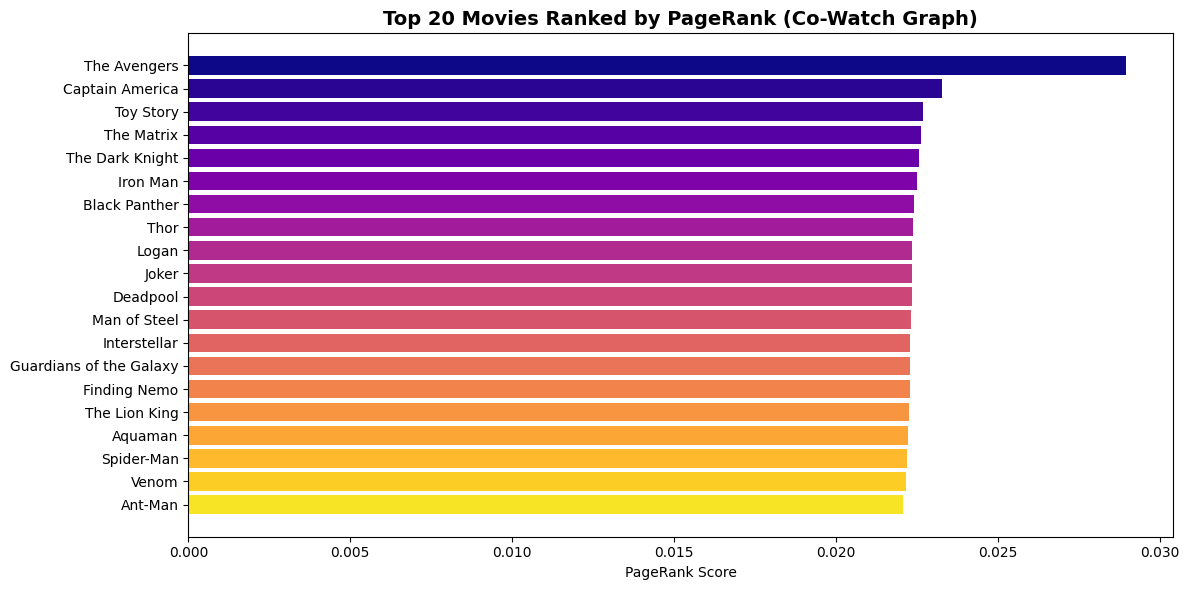

In [56]:
top_pr =pagerank_df.head(20)

plt.figure(figsize=(12, 6))
colors_pr = plt.cm.plasma([i/20 for i in range(20)])
plt.barh(top_pr['Movie'][::-1], top_pr['PageRank'][::-1], color=colors_pr[::-1])
plt.title('Top 20 Movies Ranked by PageRank (Co-Watch Graph)', fontsize=14, fontweight='bold')
plt.xlabel('PageRank Score')
plt.tight_layout()
plt.savefig('pagerank_top20.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualization 4: Frequent Movie Pair Co-Watch Graph

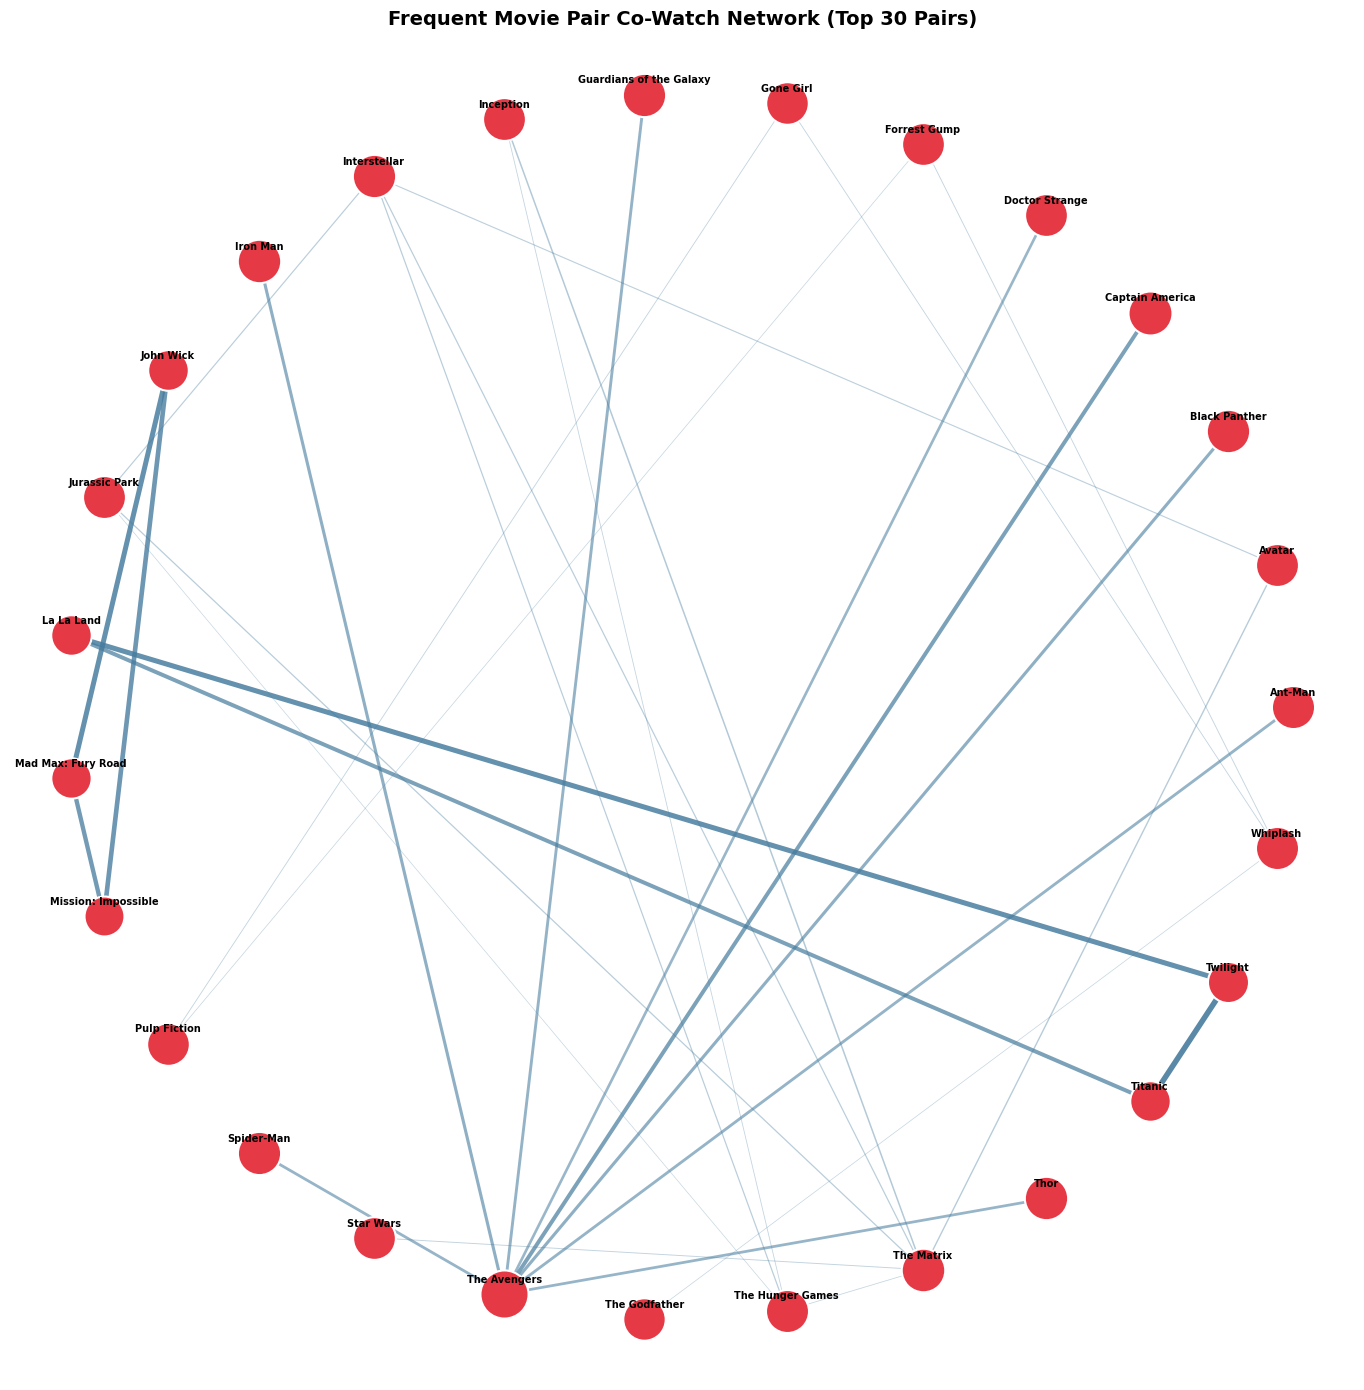

Co-watch pair graph saved.


In [57]:
# Build edge list: top 30 pairs by co-watch count
edge_list = []
for a in co_watch:
    for b, w in co_watch[a].items():
        if a < b:
            edge_list.append((a, b, w))

edge_list.sort(key=lambda x: -x[2])
top_edges = edge_list[:30]

# Collect top nodes
top_nodes = set()
for a, b, _ in top_edges:
    top_nodes.add(a)
    top_nodes.add(b)
top_nodes = sorted(top_nodes)
n_nodes = len(top_nodes)
node_idx = {n: i for i, n in enumerate(top_nodes)}

# Circular layout
import math
angles = [2 * math.pi * i / n_nodes for i in range(n_nodes)]
pos = {node: (math.cos(angles[i]) * 3, math.sin(angles[i]) * 3)
       for i, node in enumerate(top_nodes)}

fig, ax = plt.subplots(figsize=(14, 14))
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Frequent Movie Pair Co-Watch Network (Top 30 Pairs)', fontsize=14, fontweight='bold')

max_w = max(w for _, _, w in top_edges)
min_w = min(w for _, _, w in top_edges)

# Draw edges
for a, b, w in top_edges:
    x1, y1 = pos[a]
    x2, y2 = pos[b]
    lw = 0.5 + 3.5 * (w - min_w) / (max_w - min_w + 1)
    alpha = 0.3 + 0.6 * (w - min_w) / (max_w - min_w + 1)
    ax.plot([x1, x2], [y1, y2], color='#457b9d', linewidth=lw, alpha=alpha, zorder=1)

# Draw nodes
pr_lookup = dict(zip(pagerank_df['Movie'], pagerank_df['PageRank']))
max_pr = pagerank_df['PageRank'].max()
for node, (x, y) in pos.items():
    pr = pr_lookup.get(node, 0)
    size = 200 + 1000 * (pr / max_pr)
    ax.scatter(x, y, s=size, c='#e63946', zorder=3, edgecolors='white', linewidths=1.5)
    ax.annotate(node, (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig('cowatch_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("Co-watch pair graph saved.")

## Final Combined Ranking: Popularity + PageRank

In [58]:
from collections import Counter

pop_counts = Counter(m for s in transactions for m in s)
pop_df = pd.DataFrame(list(pop_counts.items()), columns=['Movie', 'Watch_Count'])
pop_df['Watch_Count_Norm'] = pop_df['Watch_Count'] / pop_df['Watch_Count'].max()

combined = pagerank_df.merge(pop_df, on='Movie')
combined['PageRank_Norm'] = combined['PageRank'] / combined['PageRank'].max()
combined['Combined_Score'] = 0.5 * combined['PageRank_Norm'] + 0.5 * combined['Watch_Count_Norm']
combined = combined.sort_values('Combined_Score', ascending=False).reset_index(drop=True)
combined[['Movie','Watch_Count','PageRank','Combined_Score']].head(20)

,Movie,Watch_Count,PageRank,Combined_Score
0,The Avengers,1364,0.028971,1.000000
1,Twilight,927,0.019489,0.676166
2,The Matrix,734,0.022634,0.659684
3,Captain America,701,0.023279,0.658731
4,Toy Story,717,0.022691,0.654444
5,Interstellar,734,0.022299,0.653906
6,Whiplash,732,0.022033,0.648586
7,La La Land,879,0.018878,0.648020
8,Titanic,866,0.018818,0.642213
9,The Lion King,703,0.022258,0.641837


## Visualization 5: Apriori vs FP-Growth Rules — Support vs Confidence

In [59]:
import pandas as pd

results = []

for item in rules_list:
    pair = item[0]
    support = item[1]

    for stat in item[2]:
        antecedent = list(stat[0])
        consequent = list(stat[1])
        confidence = stat[2]
        lift = stat[3]

        results.append({
            'antecedents': antecedent,
            'consequents': consequent,
            'support': support,
            'confidence': confidence,
            'lift': lift
        })

rules_df = pd.DataFrame(results)

print(rules_df.head())

         antecedents        consequents   support  confidence      lift
0          [Ant-Man]    [Black Panther]  0.049060    0.554217  6.260814
1    [Black Panther]          [Ant-Man]  0.049060    0.554217  6.260814
2          [Ant-Man]  [Captain America]  0.051593    0.582831  6.236545
3  [Captain America]          [Ant-Man]  0.051593    0.552068  6.236545
4          [Ant-Man]   [Doctor Strange]  0.045327    0.512048  5.918141


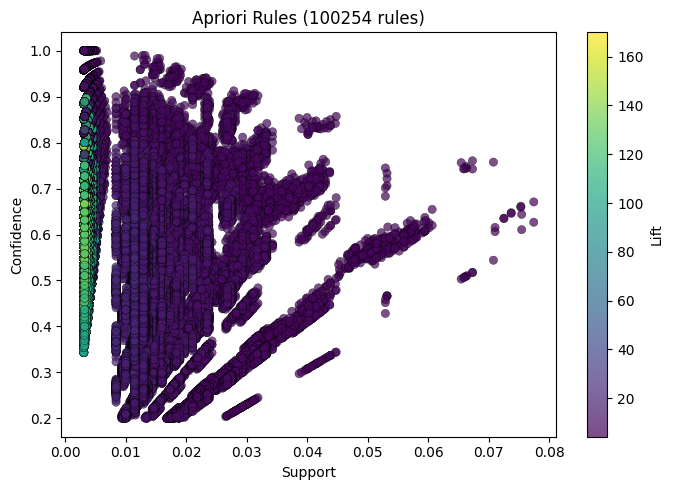

In [60]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

if len(rules_df) == 0:
    ax.set_title('No rules found')
else:
    sc = ax.scatter(
        rules_df['support'],
        rules_df['confidence'],
        c=rules_df['lift'],
        cmap='viridis',
        alpha=0.7,
        edgecolors='k',
        linewidths=0.3
    )

    ax.set_xlabel('Support')
    ax.set_ylabel('Confidence')
    ax.set_title(f'Apriori Rules ({len(rules_df)} rules)')

    plt.colorbar(sc, ax=ax, label='Lift')

plt.tight_layout()
plt.savefig('rules_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [1]:
!pip install transformers torch scikit-learn pandas numpy


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

df2= pd.read_csv('IMDB Dataset.csv')
print(df2.shape)
df2.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print(df2['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [4]:
import re

# تحويل positive/negative لـ 1/0
df2['label'] = df2['sentiment'].map({'positive': 1, 'negative': 0})

# تنظيف HTML tags زي <br />
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)   # شيل HTML
    text = re.sub(r'\s+', ' ', text)     # شيل مسافات زيادة
    return text.strip()

df2['review'] = df2['review'].apply(clean_text)

print(df2[['review', 'label']].head(3))

                                              review  label
0  One of the other reviewers has mentioned that ...      1
1  A wonderful little production. The filming tec...      1
2  I thought this was a wonderful way to spend ti...      1


In [15]:
df2_train = df2[df2['sentiment'] == 'positive'].head(500).copy()
df2_train = pd.concat([df2_train, df2[df2['sentiment'] == 'negative'].head(500)])
df2_train = df2_train.sample(frac=1, random_state=42).reset_index(drop=True)

df2_test = df2[df2['sentiment'] == 'positive'].iloc[50:55].copy()
df2_test = pd.concat([df2_test, df2[df2['sentiment'] == 'negative'].iloc[50:55]])
df2_test = df2_test.reset_index(drop=True)

x_train_text = df2_train['review'].tolist()
y_train      = df2_train['label'].tolist()

x_test_text  = df2_test['review'].tolist()
y_test       = df2_test['label'].tolist()

print(f"Train: {len(x_train_text)} — Test: {len(x_test_text)}")
print("مثال:", x_train_text[0][:100], "...")

Train: 1000 — Test: 10
مثال: It had all the clichés of movies of this type and no substance. The plot went nowhere and at the end ...


In [16]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(
    x_train_text,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    x_test_text,
    truncation=True,
    padding=True,
    max_length=128
)

print("✅ Tokenization ")
print(" encoding:", list(train_encodings.keys()))

✅ Tokenization 
 encoding: ['input_ids', 'token_type_ids', 'attention_mask']


In [17]:
import torch

class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDbDataset(train_encodings, y_train)
test_dataset  = IMDbDataset(test_encodings,  y_test)

print(f"✅ Train size: {len(train_dataset)} — Test size: {len(test_dataset)}")

✅ Train size: 1000 — Test size: 10


In [18]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2      # positive أو negative
)

print("✅ BERT  load")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2759.58it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

✅ BERT  load


In [19]:
!pip install "accelerate>=1.1.0" -q
!pip install "transformers[torch]" -q
!pip install torch -q


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir='./logs',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [21]:
trainer.train()

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


TrainOutput(global_step=250, training_loss=0.33527536010742187, metrics={'train_runtime': 1282.2565, 'train_samples_per_second': 1.56, 'train_steps_per_second': 0.195, 'total_flos': 131555527680000.0, 'train_loss': 0.33527536010742187, 'epoch': 2.0})

In [22]:
results = trainer.evaluate()
print(results)

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step
No log,0.007692,250


{'eval_loss': 0.007692014332860708}


In [23]:
def predict_sentiment(review_text):
    inputs = tokenizer(
        review_text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    )

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    pred  = torch.argmax(probs).item()
    conf  = probs[0][pred].item() * 100

    label = 'Positive ✅' if pred == 1 else 'Negative ❌'
    print(f"Review  : {review_text[:80]}...")
    print(f"Result  : {label}")
    print(f"Confidence: {conf:.1f}%")
    print("-" * 50)


# تجربة
predict_sentiment("This movie was absolutely amazing, best film I have seen in years!")
predict_sentiment("Terrible movie, complete waste of time. Boring and predictable.")

Review  : This movie was absolutely amazing, best film I have seen in years!...
Result  : Positive ✅
Confidence: 99.6%
--------------------------------------------------
Review  : Terrible movie, complete waste of time. Boring and predictable....
Result  : Negative ❌
Confidence: 99.5%
--------------------------------------------------
